# Bird diversity time series

**Goal:** Track **bird diversity** through time and relate it to **environmental and contextual features** in the same table as the observations.

**Metrics (monthly):**
- **Richness** — number of distinct species (`verbatimScientificName`)
- **Shannon \(H'\)** — from summed species × month `individualCount` (abundance-weighted)
- **Total abundance** — sum of `individualCount`
- **Evenness** — \(J = H' / \ln(S)\) when \(S>1\)

**Features** (monthly means across records): climate, NDVI, elevation, aerosol-related columns 

**Caveats:** monthly patterns mix **ecology** and **sampling effort**. Correlations are **descriptive**, not causal.


## 1. Load data and build monthly diversity + features

Parse **`eventDate`** as time, sort, aggregate to calendar **month** (`Period("M")`).


In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

PATH = "../file6.csv"

feature_cols = [
    "temp_mean",
    "rainfall",
    "wind_mean",
    "humid_mean",
    "shortwave_radiation",
    "avg_rad",
    "elevation_meters",
    "NDVI",
    "LandCover_Class",
    "Total_Aerosol_Extinction",
    "Carbon_Mass",
    "Dust_Mass",
    "SO2_Mass",
    "Sulfate_Mass",
    "Sea_Salt_Mass",
]

id_cols = ["verbatimScientificName", "individualCount", "eventDate"]
usecols = list(dict.fromkeys(id_cols + feature_cols))

df = pd.read_csv(PATH, usecols=usecols, low_memory=False)
df["Date"] = pd.to_datetime(df["eventDate"], errors="coerce")
df["individualCount"] = pd.to_numeric(df["individualCount"], errors="coerce")
df = df.dropna(subset=["Date", "verbatimScientificName", "individualCount"])
df = df.sort_values("Date")

df["cal_month"] = df["Date"].dt.month
df["year"] = df["Date"].dt.year
df["year_month"] = df["Date"].dt.to_period("M")

df["NDVI_sc"] = np.nan
if "NDVI" in df.columns:
    df["NDVI_col"] = pd.to_numeric(df["NDVI"], errors="coerce")
df["NDVI_use"] = df["NDVI_sc"].where(df["NDVI_sc"].notna(), df["NDVI_col"])

numeric_features = [
    c for c in feature_cols if c not in ("LandCover_Class", "NDVI")
]
for c in numeric_features:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")
df["NDVI_use"] = pd.to_numeric(df["NDVI_use"], errors="coerce")

df.head()


,verbatimScientificName,individualCount,eventDate,avg_rad,LandCover_Class,elevation_meters,Carbon_Mass,Dust_Mass,SO2_Mass,Sulfate_Mass,...,humid_mean,shortwave_radiation,NDVI,Date,cal_month,year,year_month,NDVI_sc,NDVI_col,NDVI_use
1003373,Centropus sinensis,1.0,2014-01-01,9.778983,13,15,6.635510e-10,1.126436e-09,2.702328e-09,3.142382e-09,...,79.64,21.57,0.4975,2014-01-01,1,2014,2014-01,NaN,0.4975,0.4975
747791,Anthus rufulus,3.0,2014-01-01,-0.019462,12,2,5.230173e-10,1.093054e-09,1.489220e-09,2.986090e-09,...,81.56,20.28,0.6461,2014-01-01,1,2014,2014-01,NaN,0.6461,0.6461
981031,Haliastur indus,4.0,2014-01-01,9.778983,13,15,6.635510e-10,1.126436e-09,2.702328e-09,3.142382e-09,...,79.64,21.57,0.4975,2014-01-01,1,2014,2014-01,NaN,0.4975,0.4975
683460,Hydrophasianus chirurgus,4.0,2014-01-01,9.778983,13,4,6.635510e-10,1.126436e-09,2.702328e-09,3.142382e-09,...,79.64,21.57,0.4962,2014-01-01,1,2014,2014-01,NaN,0.4962,0.4962
596710,Prinia inornata,2.0,2014-01-01,-0.019462,12,2,5.230173e-10,1.093054e-09,1.489220e-09,2.986090e-09,...,81.56,20.28,0.6461,2014-01-01,1,2014,2014-01,NaN,0.6461,0.6461


In [32]:
def shannon_from_counts(counts: pd.Series) -> float:
    counts = counts[counts > 0]
    if counts.empty:
        return np.nan
    p = counts / counts.sum()
    return float(-(p * np.log(p)).sum())


sp_month = (
    df.groupby(["year_month", "verbatimScientificName"], as_index=False)["individualCount"]
    .sum()
    .rename(columns={"individualCount": "abund"})
)


def monthly_diversity(g: pd.DataFrame) -> pd.Series:
    by_sp = g.groupby("verbatimScientificName")["abund"].sum()
    s = int((by_sp > 0).sum())
    h = shannon_from_counts(by_sp)
    tot = float(by_sp.sum())
    j = h / np.log(s) if s > 1 and np.isfinite(h) else np.nan
    return pd.Series({"richness": s, "shannon": h, "total_abundance": tot, "evenness": j})


div_monthly = (
    sp_month.groupby("year_month", group_keys=True)
    .apply(monthly_diversity, include_groups=False)
    .reset_index()
)

div_monthly["date"] = div_monthly["year_month"].dt.to_timestamp(how="end")

agg_feat = {c: (c, "mean") for c in numeric_features if c in df.columns}
agg_feat["NDVI_mean"] = ("NDVI_use", "mean")
if "LandCover_Class" in df.columns:
    agg_feat["landcover_mean"] = ("LandCover_Class", "mean")

features_monthly = df.groupby("year_month", as_index=False).agg(**agg_feat).sort_values("year_month")
features_monthly = features_monthly.drop(columns=[c for c in features_monthly.columns if c == "date"], errors="ignore")

ts = div_monthly.merge(features_monthly, on="year_month", how="left")

div_cols = ["richness", "shannon", "total_abundance", "evenness"]
name_map = {"NDVI": "NDVI_mean", "LandCover_Class": "landcover_mean"}
feature_ts_cols = []
for raw in feature_cols:
    col = name_map.get(raw, raw)
    if col in ts.columns:
        feature_ts_cols.append(col)

ts.head()


,year_month,richness,shannon,total_abundance,evenness,date,temp_mean,rainfall,wind_mean,humid_mean,...,avg_rad,elevation_meters,Total_Aerosol_Extinction,Carbon_Mass,Dust_Mass,SO2_Mass,Sulfate_Mass,Sea_Salt_Mass,NDVI_mean,landcover_mean
0,2014-01,284.0,4.396003,36788.0,0.778195,2014-01-31 23:59:59.999999,23.805043,3.306911,2.772102,85.395175,...,1.478005,357.268800,0.146811,5.434883e-10,1.048866e-09,1.220626e-09,2.789206e-09,2.867512e-08,0.700260,8.864369
1,2014-02,304.0,4.467692,44578.0,0.781471,2014-02-28 23:59:59.999999,24.882062,1.056820,2.275953,78.233799,...,0.918861,341.704273,0.182270,5.332217e-10,3.967178e-09,1.392533e-09,2.609239e-09,2.579532e-08,0.677752,8.827684
2,2014-03,245.0,4.309470,11140.0,0.783361,2014-03-31 23:59:59.999999,25.458234,1.577409,2.167501,76.138309,...,1.368346,342.515868,0.211332,5.719798e-10,5.851547e-09,1.360964e-09,2.296199e-09,2.748037e-08,0.665669,7.968263
3,2014-04,205.0,3.583915,7666.0,0.673287,2014-04-30 23:59:59.999999,27.080326,6.689402,1.838062,81.089022,...,0.709529,360.740942,0.230315,5.430807e-10,9.483670e-09,2.033737e-09,2.753700e-09,1.900218e-08,0.652870,9.617754
4,2014-05,68.0,3.609047,152.0,0.855324,2014-05-31 23:59:59.999999,27.042024,2.505357,3.921905,85.395238,...,1.259287,402.297619,0.230074,3.237223e-10,1.192572e-08,2.145674e-09,1.604878e-09,5.332404e-08,0.504273,9.309524


## 2. Diversity time series (national, monthly)

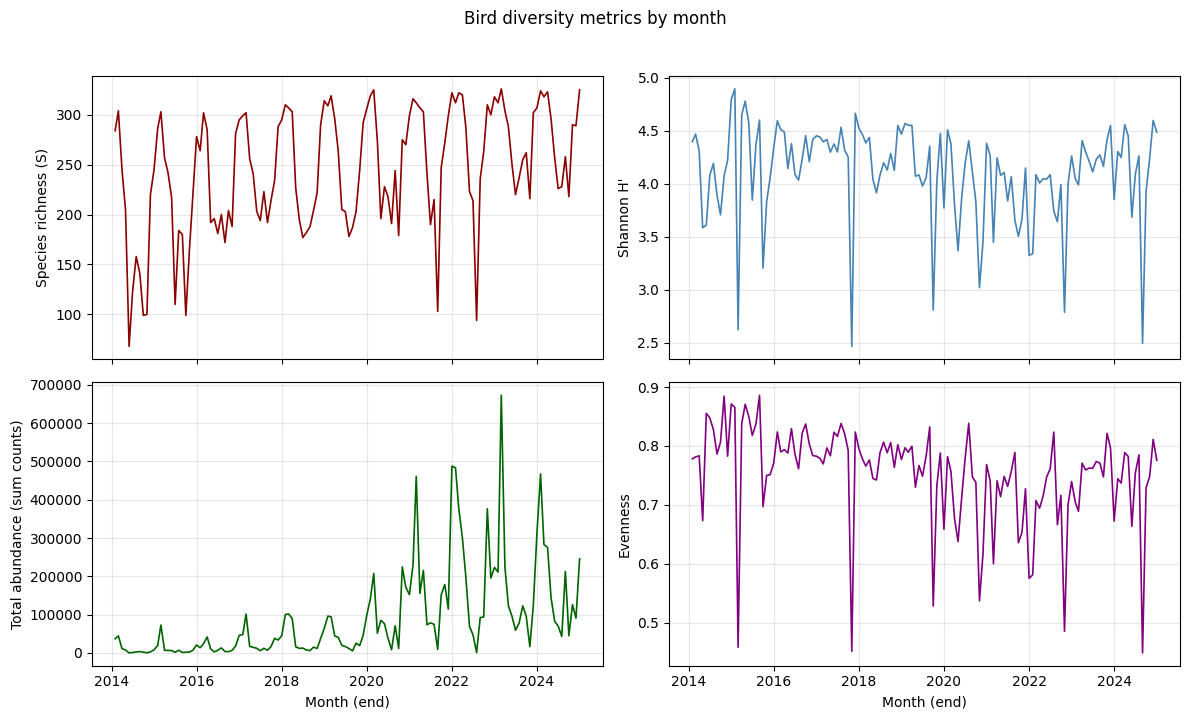

In [33]:
fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharex=True)
axes = axes.ravel()
series_defs = [
    ("richness", "Species richness (S)", "darkred"),
    ("shannon", "Shannon H'", "steelblue"),
    ("total_abundance", "Total abundance (sum counts)", "darkgreen"),
    ("evenness", "Evenness", "purple"),
]
for ax, (col, title, color) in zip(axes, series_defs):
    ax.plot(ts["date"], ts[col], color=color, lw=1.2)
    ax.set_ylabel(title)
    ax.grid(alpha=0.3)
axes[-2].set_xlabel("Month (end)")
axes[-1].set_xlabel("Month (end)")
fig.suptitle("Bird diversity metrics by month", fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig("images/div_ts_metrics.png", dpi=150, bbox_inches="tight")
plt.show()


## 4. Descriptive associations (monthly Spearman)

Pairwise correlations between diversity metrics and **all** monthly feature columns (same order as `feature_cols`).


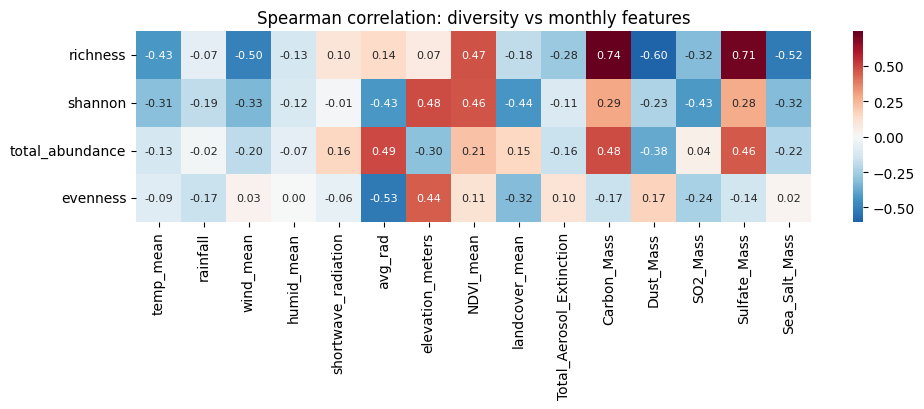

In [34]:
feats_corr = [c for c in feature_ts_cols if c in ts.columns]
if feats_corr:
    sub = ts[div_cols + feats_corr].dropna(axis=1, how="all")
    feats_corr = [c for c in feats_corr if c in sub.columns]
    if feats_corr:
        M = sub[div_cols + feats_corr].corr(method="spearman")
        w = max(10.0, 0.55 * len(feats_corr))
        plt.figure(figsize=(w, 4.2))
        sns.heatmap(
            M.loc[div_cols, feats_corr],
            annot=True,
            fmt=".2f",
            cmap="RdBu_r",
            center=0,
            annot_kws={"size": 8},
        )
        plt.title("Spearman correlation: diversity vs monthly features")
        plt.tight_layout()
        plt.savefig("images/div_ts_corr_heatmap.png", dpi=150, bbox_inches="tight")
        plt.show()


## 5. Seasonal cycle (typical year)

By **calendar month**: mean diversity and **all** mean environmental features across years. Diversity is computed from all records in each (year, month) cell. Feature panels match the same numeric fields as in section 3 (including `NDVI_use` in the year–month slice before averaging by month).


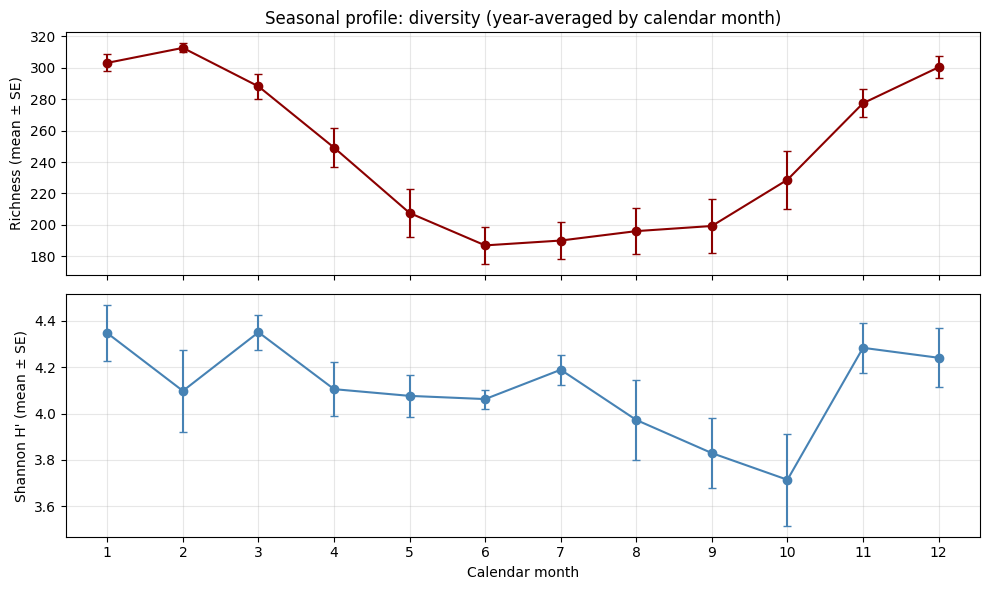

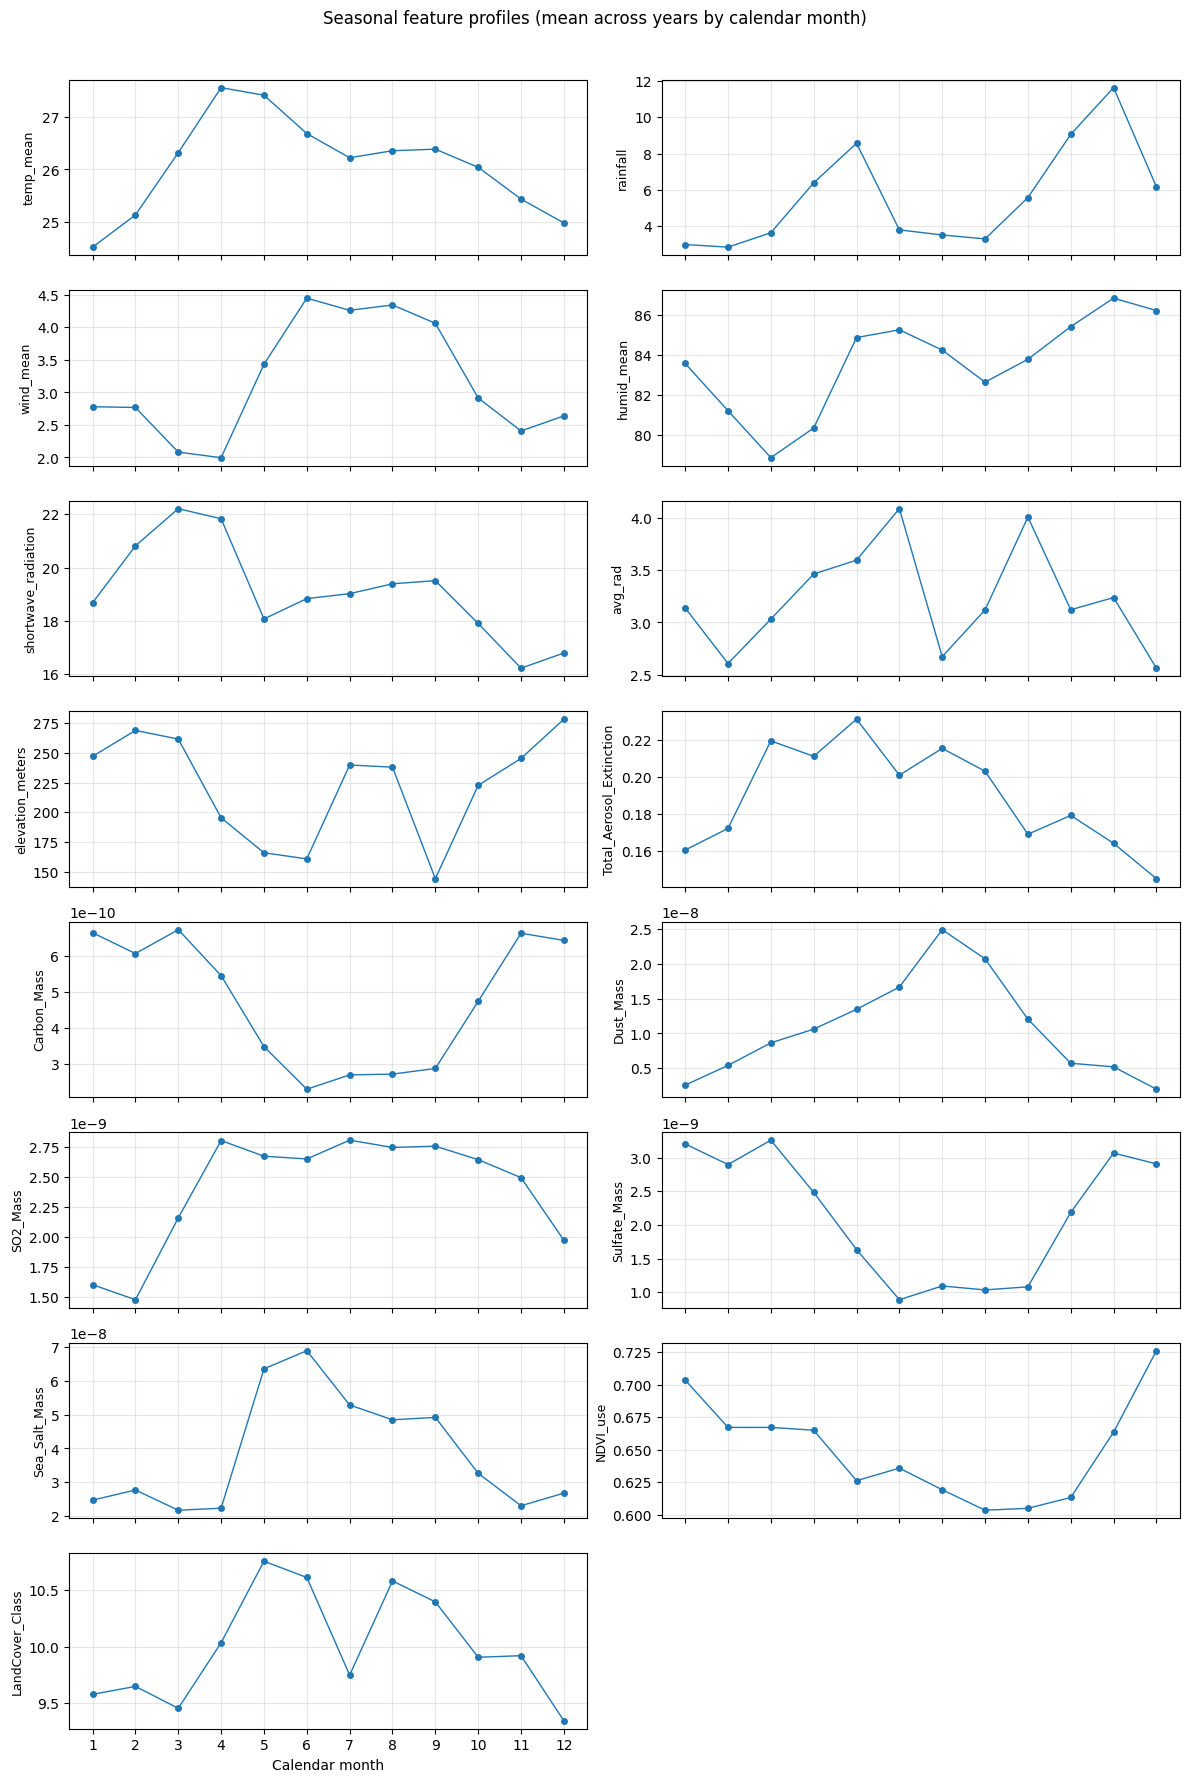

In [35]:
def month_stats_block(sub: pd.DataFrame) -> pd.Series:
    counts = sub.groupby("verbatimScientificName")["individualCount"].sum()
    s = int((counts > 0).sum())
    h = shannon_from_counts(counts)
    tot = float(counts.sum())
    j = h / np.log(s) if s > 1 and np.isfinite(h) else np.nan
    return pd.Series({"richness": s, "shannon": h, "total_abundance": tot, "evenness": j})


ym_div = (
    df.groupby(["year", "cal_month"], group_keys=True)
    .apply(month_stats_block, include_groups=False)
    .reset_index()
)


def se_mean(x):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if len(x) < 2:
        return np.nan
    return float(np.std(x, ddof=1) / np.sqrt(len(x)))


seasonal_div = (
    ym_div.groupby("cal_month", as_index=False)
    .agg(
        richness_m=("richness", "mean"),
        richness_se=("richness", se_mean),
        shannon_m=("shannon", "mean"),
        shannon_se=("shannon", se_mean),
    )
    .sort_values("cal_month")
)

feat_cols_ym = [c for c in numeric_features if c in df.columns] + (
    ["NDVI_use"] if "NDVI_use" in df.columns else []
)
if "LandCover_Class" in df.columns and "LandCover_Class" not in feat_cols_ym:
    feat_cols_ym.append("LandCover_Class")

feat_ym = df.groupby(["year", "cal_month"])[feat_cols_ym].mean().reset_index()
seasonal_feat = feat_ym.groupby("cal_month")[feat_cols_ym].mean().reset_index()

months = seasonal_div["cal_month"].values
x = np.arange(1, 13)

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
axes[0].errorbar(
    months, seasonal_div["richness_m"], yerr=seasonal_div["richness_se"], fmt="-o", color="darkred", capsize=3
)
axes[0].set_ylabel("Richness (mean ± SE)")
axes[0].grid(alpha=0.3)
axes[0].set_title("Seasonal profile: diversity (year-averaged by calendar month)")

axes[1].errorbar(
    months, seasonal_div["shannon_m"], yerr=seasonal_div["shannon_se"], fmt="-o", color="steelblue", capsize=3
)
axes[1].set_xticks(x)
axes[1].set_xlabel("Calendar month")
axes[1].set_ylabel("Shannon H' (mean ± SE)")
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig("images/div_ts_seasonal_diversity.png", dpi=150, bbox_inches="tight")
plt.show()

sf = seasonal_feat.sort_values("cal_month")
feat_season_cols = [c for c in sf.columns if c != "cal_month"]
if feat_season_cols:
    n_s = len(feat_season_cols)
    ncol_s = 2
    nrow_s = int(np.ceil(n_s / ncol_s))
    fig, axes = plt.subplots(nrow_s, ncol_s, figsize=(12, 2.2 * nrow_s), sharex=True)
    axes = np.atleast_1d(axes).ravel()
    for ax, c in zip(axes, feat_season_cols):
        ax.plot(sf["cal_month"], sf[c], "-o", lw=1.0, ms=4)
        ax.set_ylabel(c, fontsize=9)
        ax.set_xticks(x)
        ax.grid(alpha=0.3)
    for j in range(n_s, len(axes)):
        axes[j].set_visible(False)
    for j in range(n_s):
        if j // ncol_s == nrow_s - 1:
            axes[j].set_xlabel("Calendar month")
    fig.suptitle("Seasonal feature profiles (mean across years by calendar month)", y=1.01)
    plt.tight_layout()
    plt.savefig("images/div_ts_seasonal_climate.png", dpi=150, bbox_inches="tight")
    plt.show()


## Conclusion



**What the plots show**



- Diversity through time: richness swings between ~150–320 spp; Shannon stays ~3.5–4.6. Total abundance surges in recent years with sharp spikes, and evenness dips when abundance spikes, signaling dominance by a few taxa.

- Seasonality: richness is highest in Jan–Mar and again Nov–Dec, lowest May–Aug; Shannon is flatter but softens in late dry months. Error bars are modest but indicate some inter-annual spread.

- Feature seasonality: temperature peaks late austral summer, rainfall peaks at the year turn, NDVI rises late in the year, aerosols (carbon/sulfate/sea salt) and wind show mid-year bumps; 2024 monthly features broadly follow these patterns with noise.

- Same-month associations (Spearman): richness and Shannon are moderately negative with temperature, wind, and sea salt; moderately positive with NDVI and carbon/sulfate; rainfall is weak. Evenness largely mirrors Shannon but weaker.

- Lags: no strong, stable lag structure; richness shows small positive correlations when rainfall leads by 3–5 months and negative when rainfall trails (feature lag >0). Shannon–rainfall lags are weak. Treat these as exploratory, not diagnostic.



**Caveats**



- Observation bias: sampling effort and spatial mix likely drive part of the oscillations and the abundance spikes; these plots do not standardize effort.

- Descriptive, not causal: correlations and CCFs summarize co-variation, not effects. Autocorrelation and short series length limit interpretability.

- Aggregation: monthly and national means blend distinct habitats and protocols; finer spatiotemporal modeling is needed for inference.



**If you continue** add effort covariates, block by region or site, and test targeted features (e.g., NDVI, rainfall) in multivariate or mixed models to separate environment from sampling.